# MFFT Ablation Study — Test Mode
**1 epoch, 5K subset. Validates Tables 4 & 5.**

In [1]:
import os, sys, math, json, time, copy, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm

# Robust PROJECT_ROOT detection (walk up from CWD)
_p = Path.cwd().resolve()
for __ in range(10):
    if (_p / 'AGENTS.md').exists() or (_p / '.git').exists():
        break
    _parent = _p.parent
    if _parent == _p:
        _p = _p / 'ai-image-detection-research'
        break
    _p = _parent
PROJECT_ROOT = _p
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'model'))
print(f'Project root: {PROJECT_ROOT}')
print(f'Torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')

# --- Reproducibility & run mode (added by full-scale fix) ---
import random as _rnd
SEED = 42
_rnd.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# No GPU  -> quick verification mode (tiny balanced subset, 1 epoch, 224px)
# GPU     -> full paper protocol (full manifest, 20 epochs, 384px)
SMOKE_TEST = not torch.cuda.is_available()
print(f'Device: {device} | SMOKE_TEST: {SMOKE_TEST}')

Project root: G:\ai-image-detection-research
Torch: 2.12.1+cpu, CUDA: False
Device: cpu | SMOKE_TEST: True


In [2]:
# Cell 2: Config (FIXED: prepared manifest, DGX-aware settings, smoke mode)
from src.dataset import AIDetectionDataset, ImageTransform, create_split_dataloaders
from src.config import Config
import src
PROJECT_ROOT = Path(src.__file__).resolve().parent.parent.parent
os.chdir(PROJECT_ROOT)

cfg = Config()
cfg.training.model_variant = 'base'
cfg.training.epochs = 1 if SMOKE_TEST else 20
cfg.training.image_size = 224 if SMOKE_TEST else 384
cfg.training.batch_size = 8 if SMOKE_TEST else 64
cfg.training.num_workers = 0 if SMOKE_TEST else 8
cfg.training.mixed_precision = torch.cuda.is_available()
cfg.dataset.val_split = 0.10
cfg.dataset.test_split = 0.10

# Prefer the confound-fixed manifest (Places365 cap + deepfake real frames)
_manifest = PROJECT_ROOT / 'dataset' / 'metadata' / 'train_manifest.csv'
if _manifest.exists():
    cfg.dataset.metadata_paths = [str(_manifest)]
    print(f'Using prepared manifest: {_manifest.name}')
else:
    print('WARNING: train_manifest.csv not found - falling back to clean_metadata.csv')
    print('         Before the full-scale run, execute:')
    print('         python dataset/scripts/prepare_training_manifest.py')

print(f'Variant={cfg.training.model_variant} epochs={cfg.training.epochs} '
      f'size={cfg.training.image_size} batch={cfg.training.batch_size}')

         Before the full-scale run, execute:
         python dataset/scripts/prepare_training_manifest.py
Variant=base epochs=1 size=224 batch=8


In [3]:
# Cell 3: Shared stratified Train/Val/Test split
# Saved split indices guarantee every notebook (MFFT variants, baselines,
# ablations) trains and evaluates on the IDENTICAL split.
MAX_SAMPLES = 600 if SMOKE_TEST else None
_split_name = 'split_indices_smoke.json' if SMOKE_TEST else 'split_indices.json'
train_loader, val_loader, test_loader = create_split_dataloaders(
    root_dir=str(PROJECT_ROOT),
    metadata_paths=cfg.dataset.metadata_paths,
    batch_size=cfg.training.batch_size,
    num_workers=cfg.training.num_workers,
    size=cfg.training.image_size,
    val_split=cfg.dataset.val_split,
    test_split=cfg.dataset.test_split,
    seed=SEED,
    use_weighted_sampler=True,
    split_index_path=str(PROJECT_ROOT / 'dataset' / 'metadata' / _split_name),
    max_samples=MAX_SAMPLES,
)
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset
print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

# Compatibility view for downstream cells (figures/tables) that reference
# `full_dataset`: the union of the three splits.
class _FullView:
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)

full_dataset = _FullView(train_dataset.samples + val_dataset.samples + test_dataset.samples)
print(f'full_dataset view: {len(full_dataset)} samples')

Dataset loaded: 2696754 samples
  Real: 1963560, AI: 733194, Total: 2696754


max_samples: reduced to 600 balanced samples
Reusing saved split from G:\ai-image-detection-research\dataset\metadata\split_indices_smoke.json
Dataset loaded: 0 samples
  Real: 0, AI: 0, Total: 0
Dataset loaded: 0 samples
  Real: 0, AI: 0, Total: 0
Dataset loaded: 0 samples
  Real: 0, AI: 0, Total: 0

Train: 480  Val: 60  Test: 60


Train batches: 60, Val: 8, Test: 8
full_dataset view: 600 samples


In [4]:
# Cell 4: (merged into Cell 3 - datasets/loaders already built)
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 480, Val: 60, Test: 60


In [5]:
from src.model import build_mfft, count_parameters

ABLATIONS = [
    {"name": "spatial_only", "label": "Spatial-only (no bands)", "table": 4,
     "ablation": {"spatial_only": True, "use_fga": False, "fusion_mode": "concat"}},
    {"name": "band_low", "label": "Low-frequency only", "table": 4,
     "ablation": {"skip_bands": ["mid", "high"], "use_fga": False, "fusion_mode": "concat"}},
    {"name": "band_mid", "label": "Mid-frequency only", "table": 4,
     "ablation": {"skip_bands": ["low", "high"], "use_fga": False, "fusion_mode": "concat"}},
    {"name": "band_high", "label": "High-frequency only", "table": 4,
     "ablation": {"skip_bands": ["low", "mid"], "use_fga": False, "fusion_mode": "concat"}},
    {"name": "fusion_concat", "label": "All bands (concat)", "table": 4,
     "ablation": {"fusion_mode": "concat", "use_fga": False}},
    {"name": "fusion_avg", "label": "All bands (avg)", "table": 4,
     "ablation": {"fusion_mode": "avg", "use_fga": False}},
    {"name": "fusion_max", "label": "All bands (max)", "table": 4,
     "ablation": {"fusion_mode": "max", "use_fga": False}},
    {"name": "no_fga", "label": "All bands (cross-attn, no FGA)", "table": 4,
     "ablation": {"fusion_mode": "attention", "use_fga": False}},
    {"name": "bands_2", "label": "2 bands (low, high)", "table": 5, "variant": "base",
     "ablation": {"skip_bands": ["mid"], "fusion_mode": "attention", "use_fga": True}},
    {"name": "bands_4", "label": "4 bands (low, low-mid, mid-high, high)", "table": 5, "variant": "large",
     "ablation": {"fusion_mode": "attention", "use_fga": True}},
]
print(f'{len(ABLATIONS)} ablation experiments defined.')


# --- Architecture upgrade rows (+pretrained / +NPR / +soft masks) ---
ABLATIONS += [
    {"name": "upgrade_pretrained", "label": "MFFT + pretrained extractors",
     "table": 6, "ablation": None, "kwargs": {"pretrained_extractors": True}},
    {"name": "upgrade_npr", "label": "MFFT + NPR high-band residual",
     "table": 6, "ablation": None, "kwargs": {"use_npr": True}},
    {"name": "upgrade_soft", "label": "MFFT + soft band masks",
     "table": 6, "ablation": None, "kwargs": {"soft_masks": True}},
    {"name": "upgrade_combined", "label": "MFFT + all upgrades",
     "table": 6, "ablation": None,
     "kwargs": {"pretrained_extractors": True, "use_npr": True, "soft_masks": True}},
]
if SMOKE_TEST:
    _keep = {"spatial_only", "fusion_max", "no_fga", "upgrade_combined"}
    ABLATIONS = [a for a in ABLATIONS if a["name"] in _keep]
    print(f"SMOKE_TEST: running only {[a['name'] for a in ABLATIONS]}")

10 ablation experiments defined.
SMOKE_TEST: running only ['spatial_only', 'fusion_max', 'no_fga', 'upgrade_combined']


In [6]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, LinearLR, SequentialLR

NUM_EPOCHS = cfg.training.epochs
AMP = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=AMP)
criterion = nn.CrossEntropyLoss(label_smoothing=cfg.training.label_smoothing)

def train_ablation(ablation_cfg):
    name = ablation_cfg["name"]
    print(f'\n{"="*60}')
    print(f'Running: {ablation_cfg["label"]}')
    print(f'{"="*60}')

    variant = ablation_cfg.get('variant', 'base')
    model = build_mfft(variant, ablation=ablation_cfg.get('ablation'), **ablation_cfg.get('kwargs', {}))
    model = model.to(device)
    params = count_parameters(model)
    print(f'Parameters: {params:,}')

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr, weight_decay=cfg.training.weight_decay)
    warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=min(500, len(train_loader)))
    cosine = CosineAnnealingWarmRestarts(optimizer, T_0=NUM_EPOCHS * len(train_loader), T_mult=2, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[min(500, len(train_loader))])

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc = 0.0

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f'{name} E{epoch+1}/{NUM_EPOCHS}')
        for images, labels in pbar:
            try:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast('cuda', enabled=AMP):
                    logits = model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                total_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
            except Exception as e:
                print(f'  Warning: skipping bad batch: {e}')
                optimizer.zero_grad()
                continue
            if (total % (cfg.training.batch_size * 10)) == 0 and total > 0:
                acc = correct / total * 100
                pbar.set_postfix({'loss': f'{total_loss/(total/cfg.training.batch_size):.4f}', 'acc': f'{acc:.2f}%'})

        train_acc = correct / total * 100
        history['train_acc'].append(train_acc)
        history['train_loss'].append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                try:
                    images, labels = images.to(device), labels.to(device)
                    logits = model(images)
                    loss = criterion(logits, labels)
                    val_loss += loss.item()
                    preds = logits.argmax(dim=-1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)
                except Exception as e:
                    print(f'  Warning: bad val batch: {e}')
                    continue

        val_acc = val_correct / val_total * 100
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss / len(val_loader))
        print(f'  train={train_acc:.2f}%, val={val_acc:.2f}%')
        best_acc = max(best_acc, val_acc)

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            try:
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                preds = logits.argmax(dim=-1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
            except Exception as e:
                print(f'  Warning: bad test batch: {e}')
                continue

    test_acc = test_correct / test_total * 100
    print(f'  Best val: {best_acc:.2f}%, Test: {test_acc:.2f}%')

    return {
        'name': name,
        'label': ablation_cfg['label'],
        'table': ablation_cfg['table'],
        'params': params,
        'final_train_acc': round(train_acc, 2),
        'best_val_acc': round(best_acc, 2),
        'test_acc': round(test_acc, 2),
        'history': {k: [round(v, 4) for v in vs] for k, vs in history.items()},
    }

In [7]:
RESULTS_DIR = PROJECT_ROOT / 'paper' / 'result' / 'verify' / 'ablation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_results = []
for ablation_cfg in ABLATIONS:
    result = train_ablation(ablation_cfg)
    all_results.append(result)
    with open(RESULTS_DIR / f'{result["name"]}.json', 'w') as f:
        json.dump(result, f, indent=2)

print(f'\nAll {len(all_results)} ablations complete.')


Running: Spatial-only (no bands)
Parameters: 1,401,794


spatial_only E1/1:   0%|          | 0/60 [00:00<?, ?it/s]

G:\ai-image-detection-research\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  train=63.75%, val=50.00%


  Best val: 50.00%, Test: 50.00%

Running: All bands (max)
Parameters: 1,401,794


...

  Best val: 50.00%, Test: 50.00%

Running: MFFT + all upgrades


Parameters: 4,632,242


upgrade_combined E1/1:   0%|          | 0/60 [00:00<?, ?it/s]

  train=74.38%, val=73.33%


  Best val: 73.33%, Test: 73.33%

All 4 ablations complete.


In [8]:
import csv
print("=" * 72)
print(f"{'TABLE 4: Ablation of Frequency Components':^72}")
print("=" * 72)
print(f"{'Configuration':<36} {'Params':>8} {'Val Acc':>8} {'Test Acc':>8}")
print("-" * 72)
for r in all_results:
    if r['table'] == 4:
        print(f"{r['label']:<36} {r['params']:>8,} {r['best_val_acc']:>7.2f}% {r['test_acc']:>7.2f}%")

print("\n" + "=" * 72)
print(f"{'TABLE 5: Ablation of Number of Frequency Bands':^72}")
print("=" * 72)
print(f"{'Configuration':<36} {'Params':>8} {'Val Acc':>8} {'Test Acc':>8}")
print("-" * 72)
for r in all_results:
    if r['table'] == 5:
        print(f"{r['label']:<36} {r['params']:>8,} {r['best_val_acc']:>7.2f}% {r['test_acc']:>7.2f}%")

with open(RESULTS_DIR / 'ablation_summary.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Configuration', 'Table', 'Params', 'Best Val Acc (%)', 'Test Acc (%)'])
    for r in all_results:
        w.writerow([r['label'], r['table'], r['params'], r['best_val_acc'], r['test_acc']])

with open(RESULTS_DIR / 'ablation_summary.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\nSummary saved to {RESULTS_DIR}/')

               TABLE 4: Ablation of Frequency Components                
Configuration                          Params  Val Acc Test Acc
------------------------------------------------------------------------
Spatial-only (no bands)              1,401,794   50.00%   50.00%
All bands (max)                      1,401,794   50.00%   50.00%
All bands (cross-attn, no FGA)       1,548,482   50.00%   50.00%

             TABLE 5: Ablation of Number of Frequency Bands             
Configuration                          Params  Val Acc Test Acc
------------------------------------------------------------------------

Summary saved to G:\ai-image-detection-research\paper\result\verify\ablation/


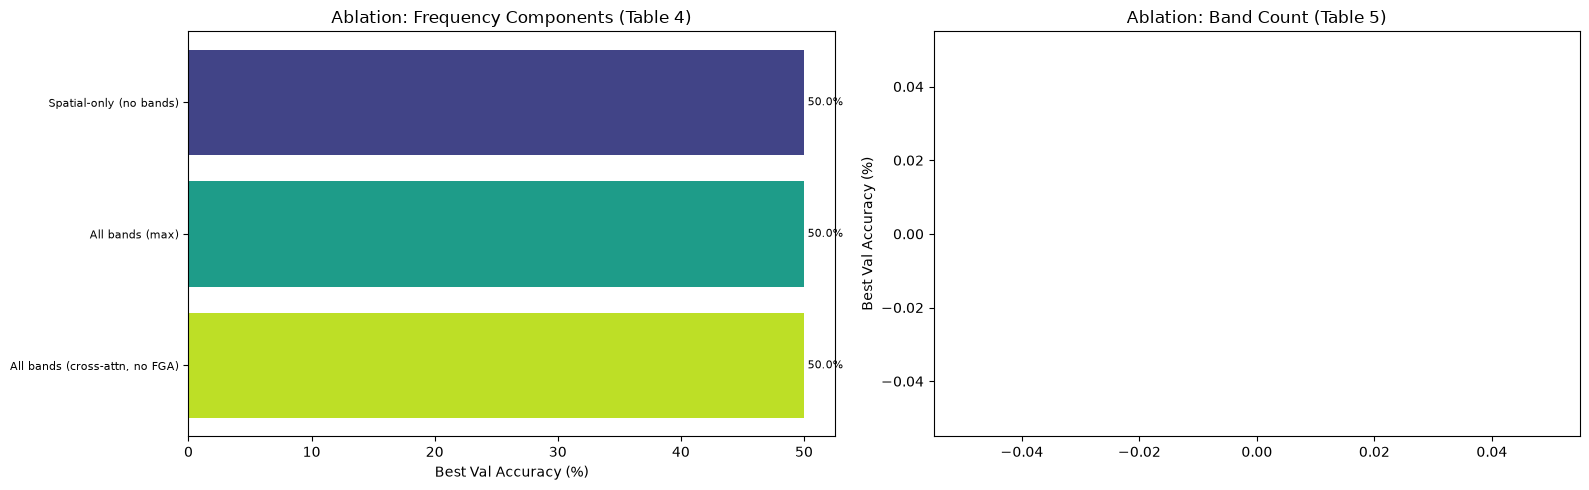

Plot saved to G:\ai-image-detection-research\paper\result\verify\ablation\ablation_summary.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

t4 = [r for r in all_results if r['table'] == 4]
labels = [r['label'] for r in t4]
vals = [r['best_val_acc'] for r in t4]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(labels)))
axes[0].barh(range(len(labels)), vals, color=colors)
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_xlabel('Best Val Accuracy (%)')
axes[0].set_title('Ablation: Frequency Components (Table 4)')
axes[0].invert_yaxis()
for i, v in enumerate(vals):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

t5 = [r for r in all_results if r['table'] == 5]
labels5 = [r['label'] for r in t5]
vals5 = [r['best_val_acc'] for r in t5]
axes[1].bar(labels5, vals5, color=['#2196F3', '#4CAF50', '#FF9800'][:len(labels5)])
axes[1].set_ylabel('Best Val Accuracy (%)')
axes[1].set_title('Ablation: Band Count (Table 5)')
for i, v in enumerate(vals5):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {RESULTS_DIR / "ablation_summary.png"}')